# Network Analysis

User interaction networks across 4 music subreddits. Each node is a user, each edge means one user replied to another.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from collections import Counter

from community import community_louvain

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/all_subreddits_sample.csv")
print(df.shape)
df[["author", "parent_id", "link_id", "subreddit"]].head()

(40000, 10)


,author,parent_id,link_id,subreddit
0,WakaIsMyWaifu,t1_ctneflp,t3_3fcixz,hiphopheads
1,n8-dohg,t1_ctneet0,t3_3fcixz,hiphopheads
2,Big_E33,t1_ctndpm1,t3_3fcixz,hiphopheads
3,Keeks_marone,t1_ctnf2as,t3_3fc5yn,hiphopheads
4,MrBokbagok,t1_ctmzh29,t3_3fagto,hiphopheads


## 1. Budowa sieci

In [3]:
# parent_id zaczyna sie od t1_ jesli to odpowiedz na komentarz
# t3_ oznacza odpowiedz na post (nie interesuje nas)
replies = df[df["parent_id"].str.startswith("t1_", na=False)].copy()

replies["parent_comment_id"] = replies["parent_id"].str[3:]

# laczemy z oryginalnym df zeby znalezc autora rodzica
edges = replies.merge(
    df[["comment_id", "author"]].rename(columns={"author": "parent_author"}),
    left_on="parent_comment_id",
    right_on="comment_id",
    how="inner"
)

# usuwamy self-loops
edges = edges[edges["author"] != edges["parent_author"]]

print(f"Znaleziono {len(edges)} krawedzi")
edges[["subreddit", "author", "parent_author"]].head(10)

Znaleziono 23635 krawedzi


,subreddit,author,parent_author
0,hiphopheads,ObieUno,SoberDreams
1,hiphopheads,SoberDreams,pull_me_aside
2,hiphopheads,l5555l,Keeks_marone
3,hiphopheads,cinic,Crayons1
4,hiphopheads,mousecop78,thatniggajigga
5,hiphopheads,-hondo-,Big_E33
6,hiphopheads,SavageCulture,Itarum
7,hiphopheads,ObieUno,Swiftt
8,hiphopheads,buges,mikeaveli2682
9,hiphopheads,SoberDreams,ObieUno


In [4]:
graphs = {}

for sub, group in edges.groupby("subreddit"):
    G = nx.DiGraph()
    
    for _, row in group.iterrows():
        G.add_edge(row["author"], row["parent_author"])
    
    graphs[sub] = G
    print(f"r/{sub}: {G.number_of_nodes()} wezlow, {G.number_of_edges()} krawedzi")

r/Metal: 1745 wezlow, 4745 krawedzi
r/hiphopheads: 2862 wezlow, 5067 krawedzi
r/indieheads: 1426 wezlow, 5260 krawedzi
r/popheads: 882 wezlow, 3627 krawedzi


## 2. Podstawowe metryki

In [5]:
metrics = []

for sub, G in graphs.items():
    G_und = G.to_undirected()
    degrees = [d for _, d in G_und.degree()]
    
    metrics.append({
        "subreddit":   sub,
        "nodes":       G.number_of_nodes(),
        "edges":       G.number_of_edges(),
        "density":     round(nx.density(G_und), 4),
        "avg_degree":  round(np.mean(degrees), 2),
        "max_degree":  max(degrees),
    })

metrics_df = pd.DataFrame(metrics).set_index("subreddit")
metrics_df

,nodes,edges,density,avg_degree,max_degree
subreddit,,,,,
Metal,1745,4745,0.0023,4.05,150
hiphopheads,2862,5067,0.0010,2.93,45
indieheads,1426,5260,0.0040,5.71,137
popheads,882,3627,0.0072,6.35,144


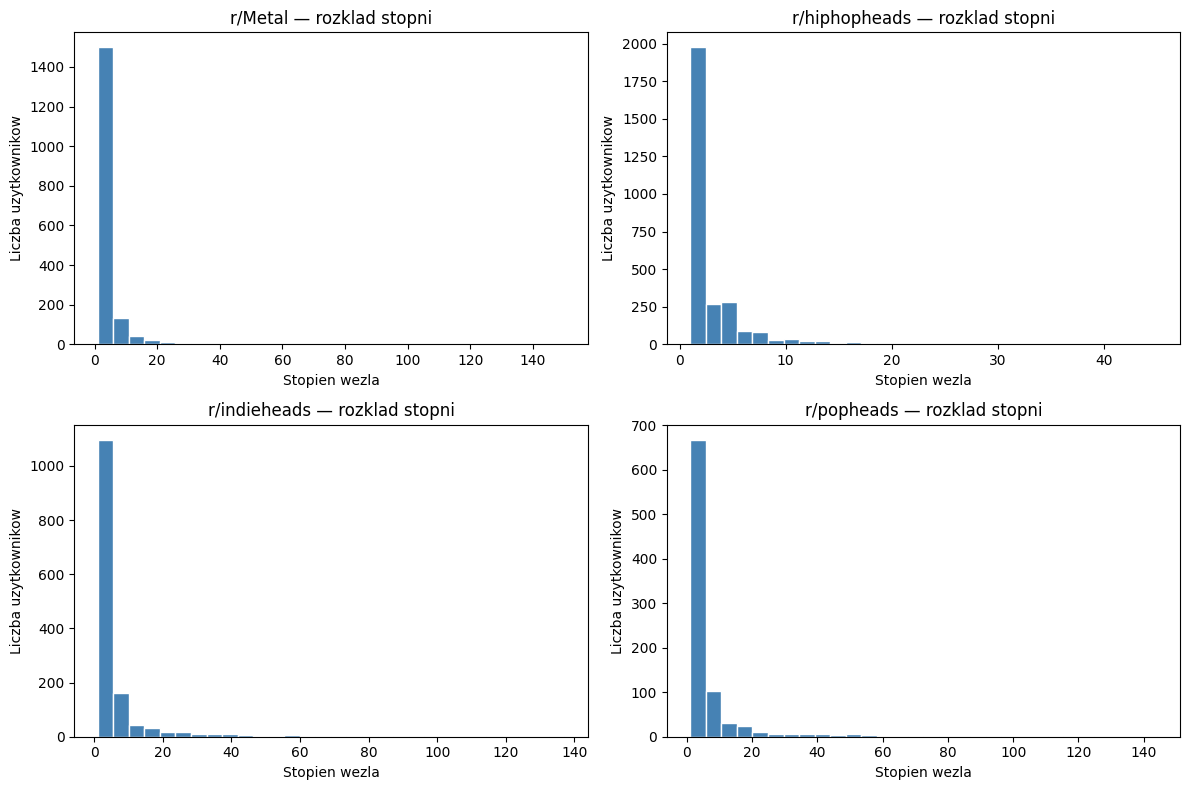

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    G_und = G.to_undirected()
    degrees = [d for _, d in G_und.degree()]
    
    axes[i].hist(degrees, bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(f"r/{sub} — rozklad stopni")
    axes[i].set_xlabel("Stopien wezla")
    axes[i].set_ylabel("Liczba uzytkownikow")

plt.tight_layout()
plt.savefig("../outputs/figures/degree_distribution.png", dpi=150)
plt.show()

## 3. Centralnosc

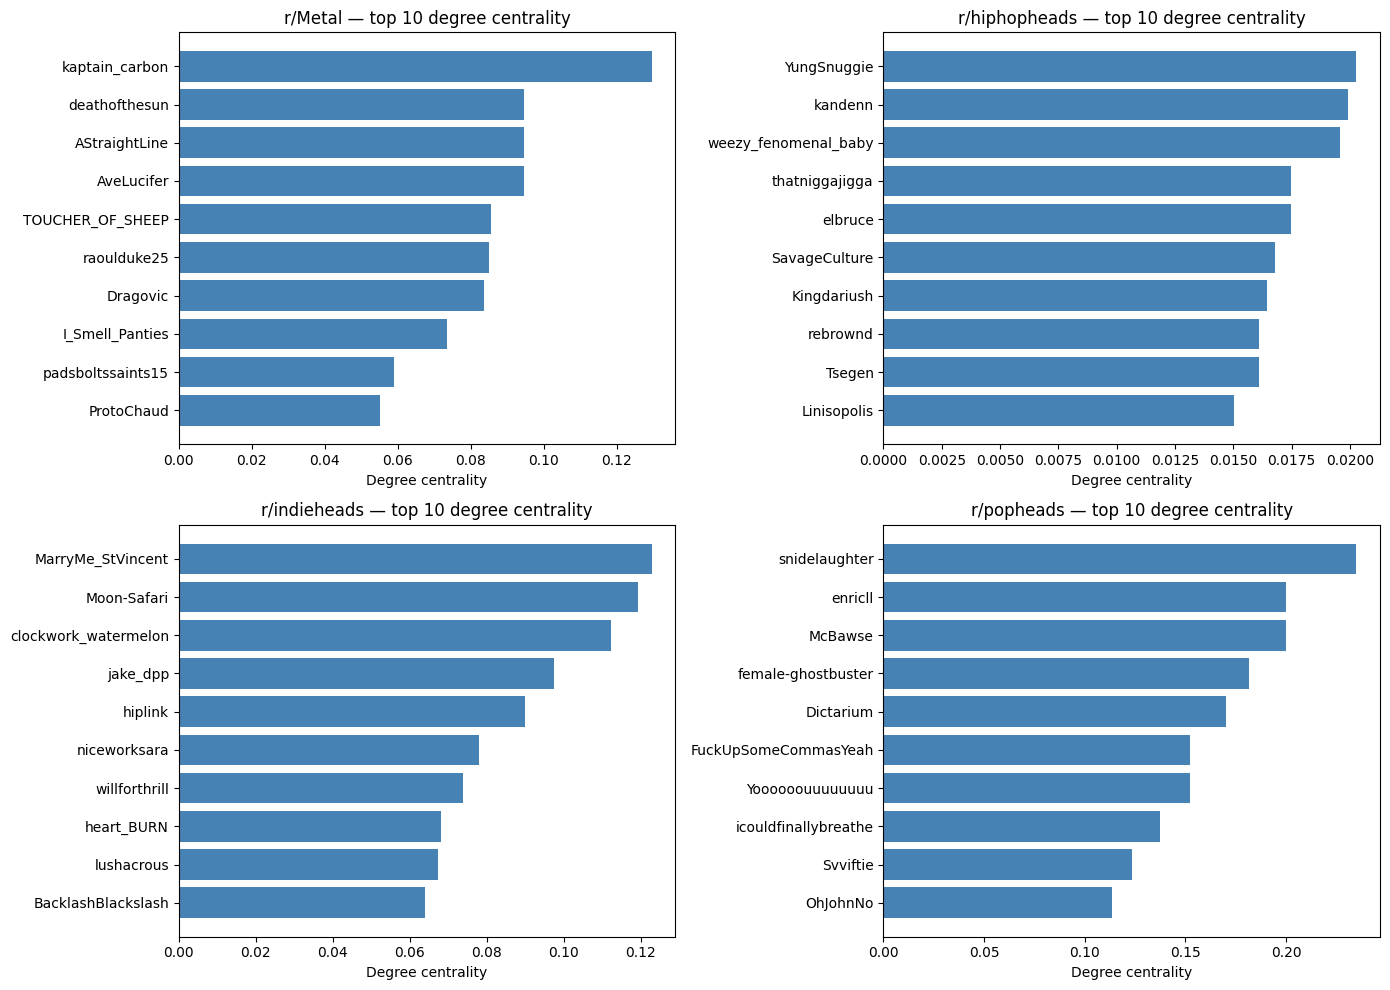

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    degree_cent = nx.degree_centrality(G)
    top = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    
    axes[i].barh(users, values, color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 degree centrality")
    axes[i].set_xlabel("Degree centrality")

plt.tight_layout()
plt.savefig("../outputs/figures/degree_centrality.png", dpi=150)
plt.show()

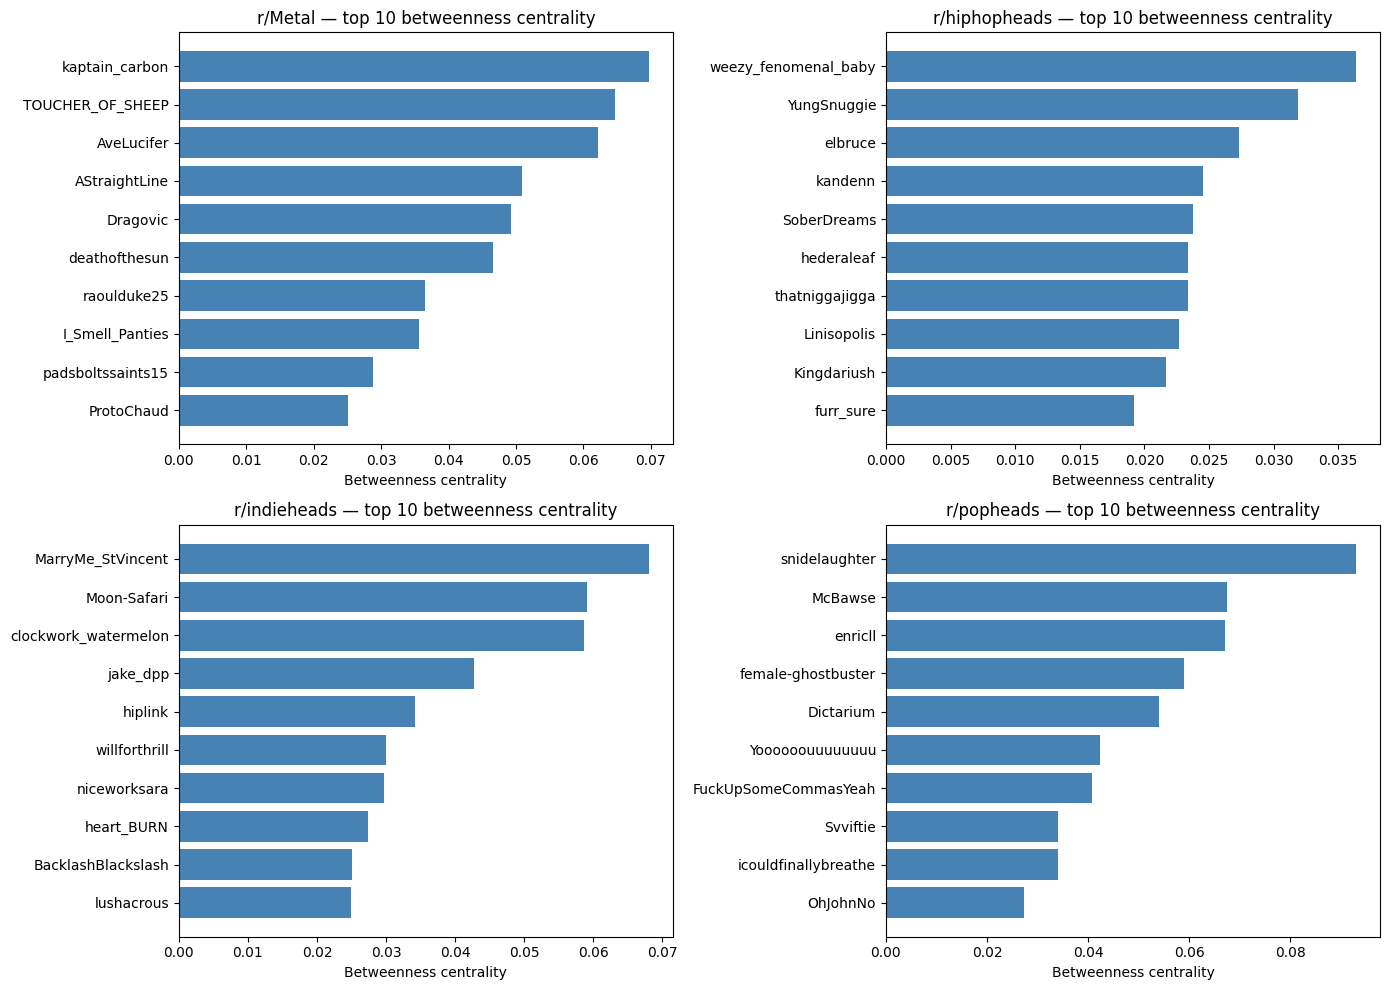

In [8]:
# betweenness centrality — moze chwile poterwac
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    between_cent = nx.betweenness_centrality(G)
    top = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    
    axes[i].barh(users, values, color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 betweenness centrality")
    axes[i].set_xlabel("Betweenness centrality")

plt.tight_layout()
plt.savefig("../outputs/figures/betweenness_centrality.png", dpi=150)
plt.show()

## 4. Wykrywanie spolecznosci (Louvain)

In [9]:
community_stats = []

for sub, G in graphs.items():
    G_und = G.to_undirected()
    partition = community_louvain.best_partition(G_und)
    
    num_communities = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, G_und)
    sizes = Counter(partition.values())
    largest = max(sizes.values())
    
    community_stats.append({
        "subreddit":         sub,
        "communities":       num_communities,
        "modularity":        round(modularity, 3),
        "largest_community": largest,
    })
    
    nx.set_node_attributes(G, partition, "community")

community_df = pd.DataFrame(community_stats).set_index("subreddit")
community_df

,communities,modularity,largest_community
subreddit,,,
Metal,85,0.510,154
hiphopheads,167,0.697,237
indieheads,46,0.396,160
popheads,29,0.339,104


## 5. Wizualizacja sieci

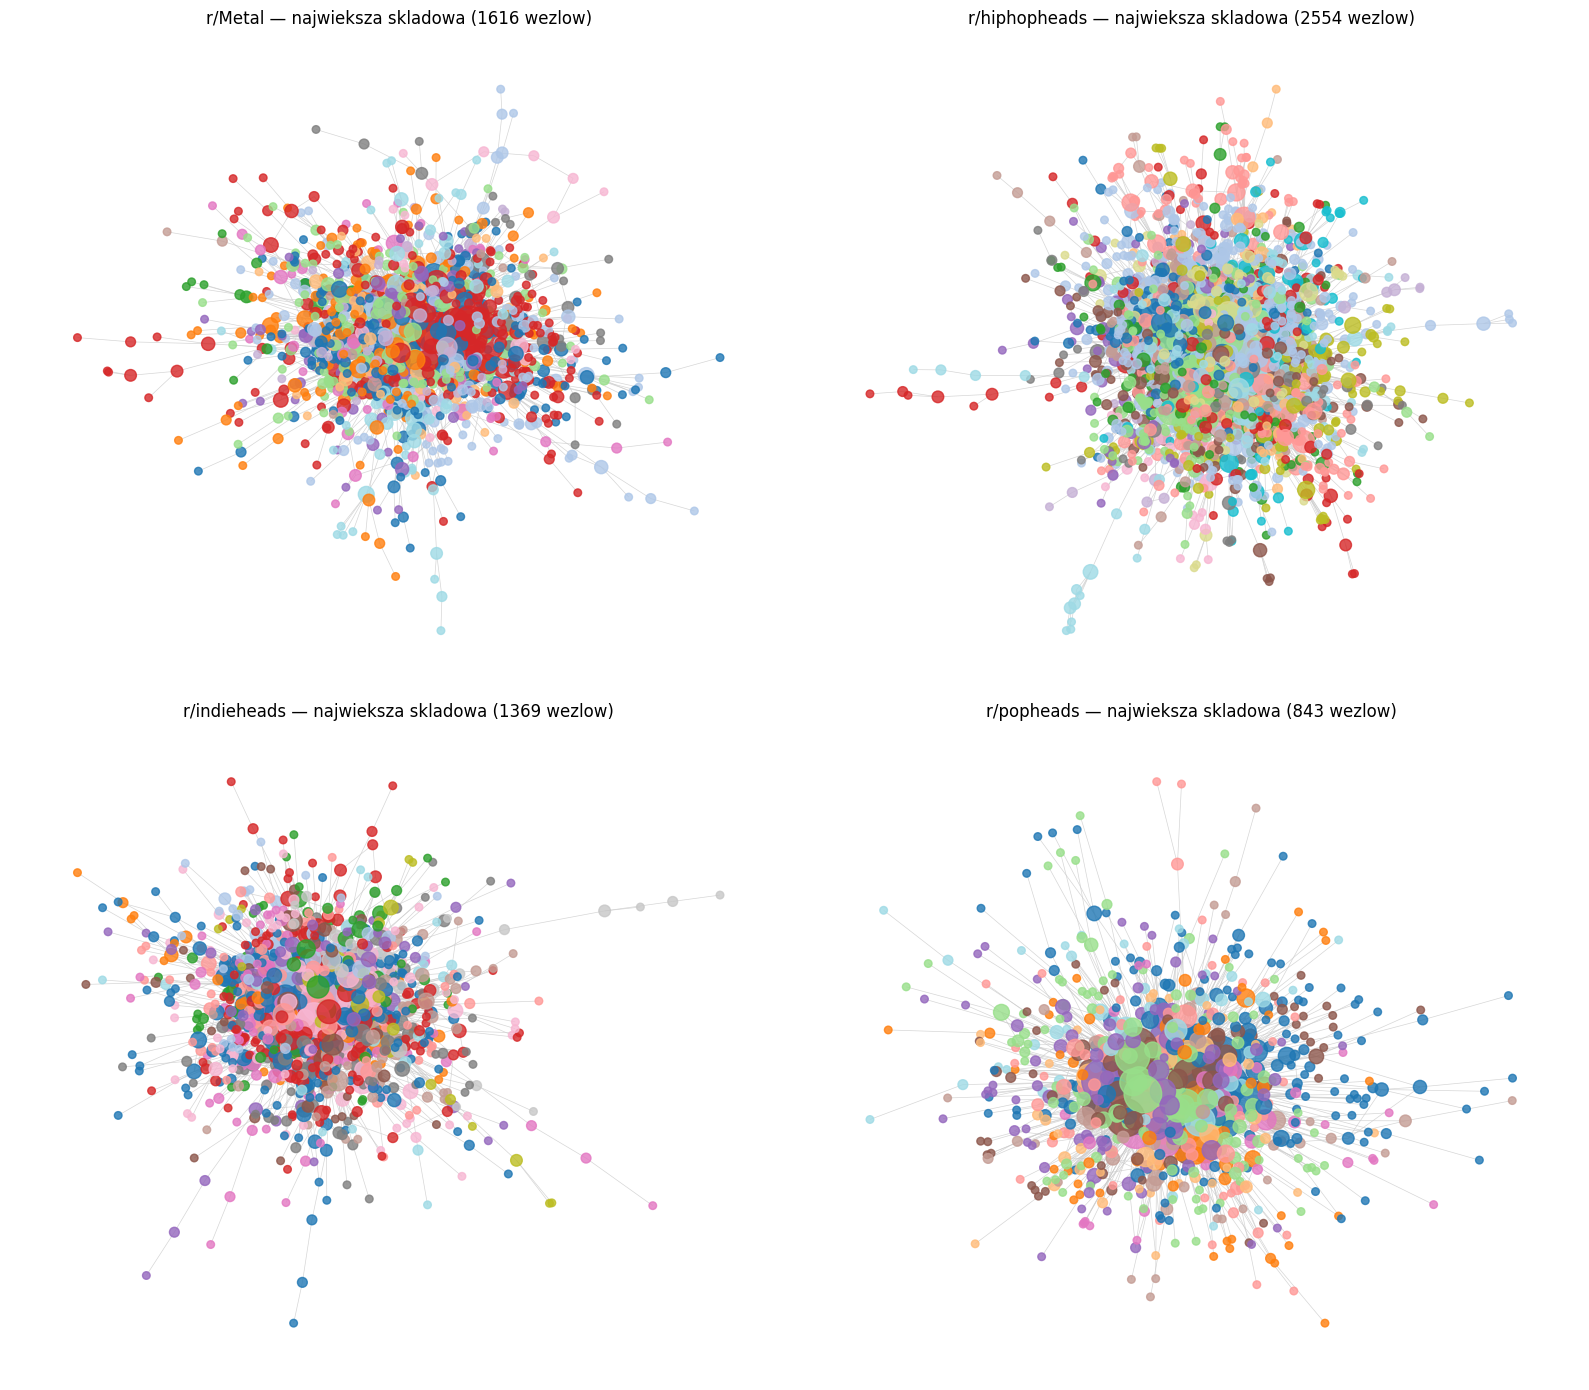

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    ax = axes[i]
    G_und = G.to_undirected()
    
    # bierzemy najwieksza spojna skladowa zeby wykres byl czytelny
    largest_cc = max(nx.connected_components(G_und), key=len)
    G_sub = G_und.subgraph(largest_cc)
    
    pos = nx.spring_layout(G_sub, seed=42, k=0.5)
    
    communities = nx.get_node_attributes(G, "community")
    node_colors = [communities.get(n, 0) for n in G_sub.nodes()]
    
    degrees = dict(G_sub.degree())
    node_sizes = [degrees[n] * 20 + 10 for n in G_sub.nodes()]
    
    nx.draw_networkx(
        G_sub,
        pos=pos,
        ax=ax,
        with_labels=False,
        node_color=node_colors,
        node_size=node_sizes,
        edge_color="#cccccc",
        width=0.5,
        cmap=plt.cm.tab20,
        alpha=0.8,
    )
    
    ax.set_title(f"r/{sub} — najwieksza skladowa ({len(G_sub)} wezlow)")
    ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/network_communities.png", dpi=150)
plt.show()

## Wnioski

- ...
- ...
- ...